# Triplet Network

## Import Libraries

In [2]:
!pip install datasets -q

import os
import datasets
import numpy as np
import pandas as pd
from tqdm import tqdm
tqdm.pandas()
import torch
from PIL import Image
from torchvision import transforms
import torchvision
import matplotlib.pyplot as plt
import json
import requests
%matplotlib inline

# import warnings
# warnings.filterwarnings('ignore')


## Configuration

In [4]:
import os
from pathlib import Path
import torch
from torchvision import transforms

class Config:
    """
    Configuration class for the project.
    """
    # ========== Base Paths ==========
    project_name = "logo_recognition_similarity_search_project"
    base_dir = Path("/content/drive/MyDrive")/project_name
    output_dir = base_dir / "output"
    cache_dir = base_dir / "cache"

    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(cache_dir, exist_ok=True)

    # ========== Dataset ==========
    dataset_path = "mlproject5606/Logo-Recognition-Category-ResNet50-Backbone-Embeddings-Dataset-V2"
    dataset_cache_dir = cache_dir / dataset_path.split("/")[-1]
    category_indices_cache_dir = cache_dir / "Category-Indices" / dataset_path.split("/")[-1]
    image_size = 128
    batch_size = 2000
    seed = 42
    transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]),
            ])


    # ========== Runtime ==========
    device = "cuda" if torch.cuda.is_available() else "cpu"
    num_workers = os.cpu_count()

    # ========== Model Settings ==========
    margin = 0.1


# ......................................................................
cfg = Config()

## Load Dataset

In [ ]:
# ds = datasets.load_dataset(
#     path = cfg.dataset_path,
#     split = "train",
#     )
# ds

In [5]:
ds = datasets.load_from_disk(cfg.dataset_cache_dir)
ds = ds['train']
ds

Loading dataset from disk:   0%|          | 0/192 [00:00<?, ?it/s]

Dataset({
    features: ['id', 'path', 'path_category', 'prompt', 'image', 'image_embedding', 'category'],
    num_rows: 1777584
})

In [6]:
ds.features

{'id': Value(dtype='string', id=None),
 'path': Value(dtype='string', id=None),
 'path_category': Value(dtype='string', id=None),
 'prompt': Value(dtype='string', id=None),
 'image': Image(mode='RGB', decode=True, id=None),
 'image_embedding': Sequence(feature=Sequence(feature=Sequence(feature=Value(dtype='float64', id=None), length=-1, id=None), length=-1, id=None), length=-1, id=None),
 'category': Value(dtype='int32', id=None)}

In [ ]:
ds[0]

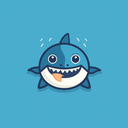

In [7]:
ds[0]['image']

In [8]:
len(ds[0]['image_embedding'])

2048

## GenericBackbone

In [160]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import Compose
from typing import List, Union, Optional, Dict
from PIL import Image


class GenericBackbone(nn.Module):
    def __init__(
        self,
        model: nn.Module,
        weights_meta: dict,
        transform: Compose,
        freeze: bool = True,
        return_layers: Optional[List[str]] = None,
        remove_layers: Optional[List[str]] = None,
        device: Optional[torch.device] = None,
    ):
        """
        Generic backbone wrapper for torchvision vision models.

        Args:
            model: Torchvision model (e.g., resnet50).
            weights_meta: Metadata from the weights object.
            transform: Recommended transform for input preprocessing.
            freeze: Whether to freeze model weights (default: True).
            return_layers: List of intermediate layers to capture via hooks.
            remove_layers: List of layer names to remove from model (e.g. ["fc"]).
            device: Device to use.
        """
        super().__init__()
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.transform = transform
        self.weights_meta = weights_meta
        self.return_layers = return_layers or []
        self.remove_layers = remove_layers or []


        # Apply remove_layers dynamically
        for layer_name in self.remove_layers:
            if hasattr(model, layer_name):
                setattr(model, layer_name, nn.Identity())

        self.model = model.to(self.device).eval()

        if freeze:
            for param in self.model.parameters():
                param.requires_grad = False

        # Prepare storage for hook outputs
        self._outputs: Dict[str, torch.Tensor] = {}
        self._register_hooks()

    def _register_hooks(self):
        """
        Register forward hooks for layers specified in return_layers.
        """
        for name, module in self.model.named_modules():
            if name in self.return_layers:
                module.register_forward_hook(self._get_hook(name))

    def _get_hook(self, name: str):
        def hook(module, input, output):
            self._outputs[name] = output.detach()
        return hook

    def _prepare_input(self, images: Union[Image.Image, List[Image.Image]]) -> torch.Tensor:
        """
        Transform PIL image(s) and prepare a batch tensor.
        """
        if isinstance(images, Image.Image):
            images = [images]
        return torch.stack([self.transform(img) for img in images]).to(self.device)


    def _get_last_valid_layer_name(self) -> Optional[str]:
        """
        Return the name of the last non-Identity layer in the model.
        """
        for name, module in reversed(list(self.model.named_modules())):
            if not isinstance(module, nn.Identity):
                return name
        return None


    def forward(self,images: Union[Image.Image, List[Image.Image]]) -> Dict[str, torch.Tensor]:
        """
        Forward pass through the model.

        Returns:
            - If return_layers are set: returns a dict of requested layer outputs.
            - If return_layers is empty: returns dict with model output under key <final_layer_name>.
        """
        self._outputs = {}

        try:
            x = self._prepare_input(images)

            with torch.no_grad():
                output = self.model(x)

            if not self.return_layers:
                last_layer_name = self._get_last_valid_layer_name()
                return {last_layer_name: output}

            return self._outputs

        except Exception as e:
            print(f"[Forward Error] {e}")
            raise e


    def predict_topk(self,logits: torch.Tensor,topk: int = 5) -> Union[List[tuple], List[List[tuple]]]:
        """
        Given model logits, return top-k class predictions and probabilities.

        Args:
            logits: Output from model (shape: [B, num_classes] or [num_classes]).
            topk: Number of top classes to return.

        Returns:
            List of {"label": ..., "score": ...} for each image.
        """
        single = logits.dim() == 1
        if single:
            logits = logits.unsqueeze(0)

        probs = F.softmax(logits, dim=1)
        values, indices = torch.topk(probs, k=topk, dim=1)

        labels = self.weights_meta["categories"]

        results = [
            [{"label": labels[idx], "score": round(values[i].item(), 5)} for i, idx in enumerate(idxs)]
            for values, idxs in zip(values, indices)
        ]

        return results[0] if single else results


In [176]:
import torchvision

weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2
model = torchvision.models.resnet50(weights=weights)

backbone = GenericBackbone(
    model=model,
    weights_meta=weights.meta,
    transform=weights.transforms(),
    freeze=True,
    remove_layers=[],
    return_layers=["avgpool","fc"]
)


In [177]:
def process_batch(batch, model: GenericBackbone, topk: int = 5):
    try:

        output = model(batch["image"])
        batch['resnet50_embedding'] = output["avgpool"]
        batch['resnet50_class'] = model.predict_topk(output["fc"], topk=topk)
        return batch

    except Exception as e:
        print(f"[Process Batch Error] {e}")
        def_error = [None] * len(batch["image"])
        batch['resnet50_embedding'] =  def_error
        batch['resnet50_class'] = def_error
        return batch

In [180]:
from functools import partial

map_fn = partial(process_batch, model=backbone, topk=5)

# 1) 777584
# 2) 1000000

n = 777584
dsn = ds.select(range(n))

dsn = dsn.map(map_fn,
              batched=True,
              batch_size=5,
              desc="Extracting ResNet50 embeddings and classes",
              )

dsn

Extracting ResNet50 embeddings and classes:   0%|          | 0/777584 [00:00<?, ? examples/s]

KeyboardInterrupt: 

In [174]:
dsn.features

{'id': Value(dtype='string', id=None),
 'path': Value(dtype='string', id=None),
 'path_category': Value(dtype='string', id=None),
 'prompt': Value(dtype='string', id=None),
 'image': Image(mode='RGB', decode=True, id=None),
 'image_embedding': Sequence(feature=Sequence(feature=Sequence(feature=Value(dtype='float64', id=None), length=-1, id=None), length=-1, id=None), length=-1, id=None),
 'category': Value(dtype='int32', id=None),
 'resnet50_embedding': Sequence(feature=Sequence(feature=Sequence(feature=Value(dtype='float32', id=None), length=-1, id=None), length=-1, id=None), length=-1, id=None),
 'resnet50_class': [{'label': Value(dtype='string', id=None),
   'score': Value(dtype='float64', id=None)}]}

In [ ]:
len(dsn[0]['resnet50_embedding']),len(dsn[0]['resnet50_class']),dsn[0]['resnet50_class']

In [ ]:
dsn.push_to_hub(
    repo_id = f"mlproject5606/Logo-Recognition-Category-ResNet50-Backbone-Embeddings-Classess-{n}-Dataset",
    private = True,
)

## Triplet Dataset

In [ ]:
from torch.utils.data import Dataset
from torchvision import transforms
import datasets
import random
from collections import defaultdict
from tqdm import tqdm
import pickle
import os

class TripletLogoDataset(Dataset):


    def __init__(self,ds: datasets.Dataset, cfg: Config, dataset_type: str = "train"):
        """
        Initialize the TripletLogoDataset.
        """

        if dataset_type not in ["train", "validation", "test"]:
            raise ValueError(f"Invalid dataset type: {dataset_type}")
        self.dataset_type = dataset_type
        self.ds = ds
        self.cfg = cfg

        os.makedirs(cfg.category_indices_cache_dir, exist_ok=True)

        if dataset_type == "train":
             self.rng = random.Random()
             category_path = os.path.join(cfg.category_indices_cache_dir, 'category_train_indices.pkl')
        elif dataset_type == "validation":
             self.rng = random.Random(cfg.seed)
             category_path = os.path.join(cfg.category_indices_cache_dir, 'category_validation_indices.pkl')
        else:
             self.rng = random.Random(cfg.seed)
             category_path = os.path.join(cfg.category_indices_cache_dir, 'category_test_indices.pkl')

        if os.path.exists(category_path):
            with open(category_path, 'rb') as f:
                self.category_to_indices = pickle.load(f)
        else:
            self.category_to_indices = self._build_category_indices()
            with open(category_path, 'wb') as f:
                pickle.dump(self.category_to_indices, f)


        self.categories = list(self.category_to_indices.keys())


    def _build_category_indices(self):
        """
        Build a dictionary of category to indices.
        """
        category_to_indices = defaultdict(list)
        for idx, example in enumerate(tqdm(self.ds, desc="Building category to indices")):
            category_to_indices[example['category']].append(idx)
        return category_to_indices

    def __len__(self):
        """
        Return the number of samples in the dataset.
        """
        return len(self.ds)

    def _get_positive_index(self, anchor_idx, category):
        """
        Get a positive index for the given anchor index and category.
        """
        positive_indices = self.category_to_indices[category][:]
        positive_indices.remove(anchor_idx)
        positive_idx = self.rng.choice(positive_indices)
        return positive_idx

    def _get_negative_index(self, anchor_idx, category):
        """
        Get a negative index for the given anchor index and category.
        """
        negative_categorys = self.categories[:]
        negative_categorys.remove(category)
        negative_category = self.rng.choice(negative_categorys)
        negative_indices = self.category_to_indices[negative_category]
        negative_idx = self.rng.choice(negative_indices)
        return negative_idx

    def __getitem__(self, idx):
        """
        Get a triplet sample from the dataset.
        """
        anchor_idx = idx
        anchor = self.ds[anchor_idx]
        category = anchor['category']

        positive_idx = self._get_positive_index(anchor_idx, category)
        positive = self.ds[positive_idx]

        negative_idx = self._get_negative_index(anchor_idx, category)
        negative = self.ds[negative_idx]

        return anchor , positive , negative


In [ ]:
triplet_train_ds = TripletLogoDataset(ds=ds, cfg=cfg, dataset_type="train")

In [ ]:
anchor , positive , negative = triplet_train_ds[4]

print(f"Anchor: {anchor['category']}")
display(anchor['image'])
print(f"\nPositive: {positive['category']}")
display(positive['image'])
print(f"\nNegative: {negative['category']}")
display(negative['image'])

## Networks

In [ ]:
import torch.nn as nn
from torchvision import models

class Backbone(nn.Module):
    """
    ResNet50 backbone for triplet network
    """
    def __init__(self,freeze: bool = True):
        """
        Initialize the backbone
        """
        super(Backbone, self).__init__()
        self.model = models.resnet50(pretrained=True)
        # Remove the last fully connected layer
        self.out_features = self.model.fc.in_features
        self.model = torch.nn.Sequential(*list(self.model.children())[:-1])
        # Freeze layers
        if freeze:
            for param in self.model.parameters():
                param.requires_grad = False


    def forward(self, x):
        """
        Forward pass of the backbone
        """
        return self.model(x)

# .............................................................................

class EmbeddingNet(nn.Module):
    """
    Embedding network for triplet network
    """
    def __init__(self, backbone, embedding_size=256):
        super(EmbeddingNet, self).__init__()
        self.backbone = backbone
        self.embedding = nn.Sequential(
            nn.Linear(self.backbone.out_features, 512),
            nn.ReLU(),
            nn.Linear(512, embedding_size)
        )

    def forward(self, x):
        """
        Forward pass of the embedding network
        """
        features = self.backbone(x)
        features = features.flatten(1)
        embedding = self.embedding(features)
        embedding = nn.functional.normalize(embedding, p=2, dim=1)
        return embedding

    def get_embedding(self, x):
        """
        Get the embedding of an input image
        """
        return self.forward(x)

# .............................................................................

class TripletNet(nn.Module):
    """
    Triplet network for logo recognition
    """
    def __init__(self, embedding_net):
        super(TripletNet, self).__init__()
        self.embedding_net = embedding_net

    def forward(self, x1, x2, x3):
        """
        Forward pass of the triplet network
        """
        output1 = self.embedding_net(x1)
        output2 = self.embedding_net(x2)
        output3 = self.embedding_net(x3)
        return output1, output2, output3

    def get_embedding(self, x):
        """
        Get the embedding of an input image
        """
        return self.embedding_net(x)


## ResNet50 Backbone Embedding

In [ ]:
backbone = Backbone(freeze=True)
backbone.model.to(cfg.device)
backbone.to(cfg.device)
backbone.eval()

In [ ]:
embedding_ds = ds.select_columns(['id','path_category','category','image'])
embedding_ds

In [ ]:
def BackboneEmbedding(examples):
    try:
        with torch.no_grad():
            images_transformed = torch.stack([cfg.transform(image) for image in examples['image']]).to(cfg.device)
            embeddings = backbone(images_transformed).cpu()
            examples['embedding'] = embeddings
        return examples

    except Exception as e:
        print(e)
        return examples

In [ ]:
embedding_ds = embedding_ds.map(BackboneEmbedding, batched=True, batch_size=cfg.batch_size,remove_columns=['image'])
embedding_ds

In [ ]:
embedding_ds.push_to_hub(
    repo_id = "mlproject5606/Logo-Recognition-Category-ResNet50-Backbone-Embeddings-Dataset",
    private = True,
)

## ResNet50 Classification

In [ ]:
import torch.nn as nn
from torchvision import models

class ResNet50Classifier(nn.Module):
    """
    ResNet50 classifier from embeddings
    """
    def __init__(self,cfg: Config, freeze: bool = True):
        super(ResNet50Classifier, self).__init__()
        self.cfg = cfg
        with open(f"{cfg.output_dir}/imagenet_classes.txt", "r") as f:
            self.classes = [line.strip() for line in f.readlines()]

        self.fc = models.resnet50(pretrained=True).fc.to(self.cfg.device)
        self.to(self.cfg.device)

        # Freeze layers
        if freeze:
            for param in self.fc.parameters():
                param.requires_grad = False

    def forward(self, x):
        x = x.reshape((-1,self.fc.in_features)).to(self.cfg.device)
        y = self.fc(x)
        y = nn.functional.softmax(y, dim=1)
        yp = torch.argmax(y, dim=1)
        yp = [self.classes[i] for i in yp]
        return yp



In [ ]:
resnet50_classifier = ResNet50Classifier(cfg,freeze=True)
resnet50_classifier.eval()

ResNet50Classifier(
  (fc): Linear(in_features=2048, out_features=1000, bias=True)
)

In [ ]:
ds = ds.remove_columns(['id','image','prompt','path'])
ds

In [ ]:
ds = ds.with_format("torch")
ds

Dataset({
    features: ['path_category', 'image_embedding', 'category'],
    num_rows: 1777584
})

In [ ]:
image_embedding = ds[:5]['image_embedding']
output = resnet50_classifier(image_embedding)
output

['snorkel', 'snorkel', 'CD player', 'CD player', 'amphibian']

In [ ]:
def resnet50_classifier_map(examples):
    global i
    try:
        with torch.no_grad():
           output = resnet50_classifier(examples['image_embedding'])
           examples['resnet50_class'] = output
        return examples
    except Exception as e:
        print(e)
        examples['resnet50_class'] = ['error'] * len(examples['image_embedding'])
        return examples

In [ ]:
ds = ds.map(resnet50_classifier_map,
            batched=True,
            batch_size=cfg.batch_size,

            )
ds

Map:   0%|          | 0/1777584 [00:00<?, ? examples/s]

In [ ]:
ds[0]

In [ ]:
ds.features

In [ ]:
ds[0]['resnet50_class']

In [ ]:
ds = ds.select_columns(['path_category', 'category', 'resnet50_class'])
ds

In [ ]:
ds.push_to_hub(
    repo_id = "mlproject5606/Logo-Recognition-Category-ResNet50-Classifier-Dataset",
    private = True,
)

## Triplet

In [ ]:
backbone = Backbone()
embedding_net = EmbeddingNet(backbone)
triplet_net = TripletNet(embedding_net)

In [ ]:
anchor_image_tensor = cfg.transform(anchor['image']).unsqueeze(0)
positive_image_tensor = cfg.transform(positive['image']).unsqueeze(0)
negative_image_tensor = cfg.transform(negative['image']).unsqueeze(0)

In [ ]:
backbone(anchor_image_tensor).shape,embedding_net(anchor_image_tensor).shape

In [ ]:
anchor_output,positive_output,negative_output = triplet_net(anchor_image_tensor,positive_image_tensor,negative_image_tensor)
anchor_output.shape,positive_output.shape,negative_output.shape

## Losses

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class TripletLoss(nn.Module):
    """
    Triplet loss
    Takes embeddings of an anchor sample, a positive sample and a negative sample
    """

    def __init__(self, margin):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative, size_average=True):
        distance_positive = (anchor - positive).pow(2).sum(1)  # .pow(.5)
        distance_negative = (anchor - negative).pow(2).sum(1)  # .pow(.5)
        losses = F.relu(distance_positive - distance_negative + self.margin)
        return losses.mean() if size_average else losses.sum()



## Metrics

In [ ]:
import numpy as np


class Metric:
    def __init__(self):
        pass

    def __call__(self, outputs, target, loss):
        raise NotImplementedError

    def reset(self):
        raise NotImplementedError

    def value(self):
        raise NotImplementedError

    def name(self):
        raise NotImplementedError


class AccumulatedAccuracyMetric(Metric):
    """
    Works with classification model
    """

    def __init__(self):
        self.correct = 0
        self.total = 0

    def __call__(self, outputs, target, loss):
        pred = outputs[0].data.max(1, keepdim=True)[1]
        self.correct += pred.eq(target[0].data.view_as(pred)).cpu().sum()
        self.total += target[0].size(0)
        return self.value()

    def reset(self):
        self.correct = 0
        self.total = 0

    def value(self):
        return 100 * float(self.correct) / self.total

    def name(self):
        return 'Accuracy'


class AverageNonzeroTripletsMetric(Metric):
    '''
    Counts average number of nonzero triplets found in minibatches
    '''

    def __init__(self):
        self.values = []

    def __call__(self, outputs, target, loss):
        self.values.append(loss[1])
        return self.value()

    def reset(self):
        self.values = []

    def value(self):
        return np.mean(self.values)

    def name(self):
        return 'Average nonzero triplets'


## Trainer

In [ ]:
import torch
import numpy as np


def fit(train_loader, val_loader, model, loss_fn, optimizer, scheduler, n_epochs, cuda, log_interval, metrics=[],
        start_epoch=0):
    """
    Loaders, model, loss function and metrics should work together for a given task,
    i.e. The model should be able to process data output of loaders,
    loss function should process target output of loaders and outputs from the model

    Examples: Classification: batch loader, classification model, NLL loss, accuracy metric
    Siamese network: Siamese loader, siamese model, contrastive loss
    Online triplet learning: batch loader, embedding model, online triplet loss
    """
    for epoch in range(0, start_epoch):
        scheduler.step()

    for epoch in range(start_epoch, n_epochs):
        scheduler.step()

        # Train stage
        train_loss, metrics = train_epoch(train_loader, model, loss_fn, optimizer, cuda, log_interval, metrics)

        message = 'Epoch: {}/{}. Train set: Average loss: {:.4f}'.format(epoch + 1, n_epochs, train_loss)
        for metric in metrics:
            message += '\t{}: {}'.format(metric.name(), metric.value())

        val_loss, metrics = test_epoch(val_loader, model, loss_fn, cuda, metrics)
        val_loss /= len(val_loader)

        message += '\nEpoch: {}/{}. Validation set: Average loss: {:.4f}'.format(epoch + 1, n_epochs,
                                                                                 val_loss)
        for metric in metrics:
            message += '\t{}: {}'.format(metric.name(), metric.value())

        print(message)


def train_epoch(train_loader, model, loss_fn, optimizer, cuda, log_interval, metrics):
    for metric in metrics:
        metric.reset()

    model.train()
    losses = []
    total_loss = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        target = target if len(target) > 0 else None
        if not type(data) in (tuple, list):
            data = (data,)
        if cuda:
            data = tuple(d.cuda() for d in data)
            if target is not None:
                target = target.cuda()


        optimizer.zero_grad()
        outputs = model(*data)

        if type(outputs) not in (tuple, list):
            outputs = (outputs,)

        loss_inputs = outputs
        if target is not None:
            target = (target,)
            loss_inputs += target

        loss_outputs = loss_fn(*loss_inputs)
        loss = loss_outputs[0] if type(loss_outputs) in (tuple, list) else loss_outputs
        losses.append(loss.item())
        total_loss += loss.item()
        loss.backward()
        optimizer.step()

        for metric in metrics:
            metric(outputs, target, loss_outputs)

        if batch_idx % log_interval == 0:
            message = 'Train: [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                batch_idx * len(data[0]), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), np.mean(losses))
            for metric in metrics:
                message += '\t{}: {}'.format(metric.name(), metric.value())

            print(message)
            losses = []

    total_loss /= (batch_idx + 1)
    return total_loss, metrics


def test_epoch(val_loader, model, loss_fn, cuda, metrics):
    with torch.no_grad():
        for metric in metrics:
            metric.reset()
        model.eval()
        val_loss = 0
        for batch_idx, (data, target) in enumerate(val_loader):
            target = target if len(target) > 0 else None
            if not type(data) in (tuple, list):
                data = (data,)
            if cuda:
                data = tuple(d.cuda() for d in data)
                if target is not None:
                    target = target.cuda()

            outputs = model(*data)

            if type(outputs) not in (tuple, list):
                outputs = (outputs,)
            loss_inputs = outputs
            if target is not None:
                target = (target,)
                loss_inputs += target

            loss_outputs = loss_fn(*loss_inputs)
            loss = loss_outputs[0] if type(loss_outputs) in (tuple, list) else loss_outputs
            val_loss += loss.item()

            for metric in metrics:
                metric(outputs, target, loss_outputs)

    return val_loss, metrics
